# Student Exam Score Prediction

## 1. Problem Definition
The goal of this project is to predict student exam scores based on various features such as study hours, sleep hours, attendance percentage, and previous scores. This is a regression problem where we aim to find the relationship between these independent variables and the target variable `exam_score`.

## 2. Dataset Collection
We will load the student exam scores dataset from the `student_exam_scores.csv` file.

In [69]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score



In [70]:
# Load the dataset
df = pd.read_csv('student_exam_scores.csv')



In [71]:
df.columns

Index(['student_id', 'hours_studied', 'sleep_hours', 'attendance_percent',
       'previous_scores', 'exam_score'],
      dtype='object')

In [72]:
# Display first few rows
df.head()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3


In [73]:
df.tail()

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0
199,S200,10.2,6.3,97.4,68,37.8


In [74]:
df.shape

(200, 6)

In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   student_id          200 non-null    object 
 1   hours_studied       200 non-null    float64
 2   sleep_hours         200 non-null    float64
 3   attendance_percent  200 non-null    float64
 4   previous_scores     200 non-null    int64  
 5   exam_score          200 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 9.5+ KB


In [76]:
df.describe()

,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,6.325500,6.622000,74.830000,66.800000,33.955000
std,3.227317,1.497138,14.249905,15.663869,6.789548
min,1.000000,4.000000,50.300000,40.000000,17.100000
25%,3.500000,5.300000,62.200000,54.000000,29.500000
50%,6.150000,6.700000,75.250000,67.500000,34.050000
75%,9.000000,8.025000,87.425000,80.000000,38.750000
max,12.000000,9.000000,100.000000,95.000000,51.300000


In [77]:
df.index

RangeIndex(start=0, stop=200, step=1)

## 3. Data Cleaning
We will check for missing values and handle them if necessary. We also need to remove any irrelevant columns like `student_id`.

In [78]:
df.isnull().sum()


student_id            0
hours_studied         0
sleep_hours           0
attendance_percent    0
previous_scores       0
exam_score            0
dtype: int64

In [79]:

# Remove 'student_id' as it's not a feature for prediction
if 'student_id' in df.columns:
    df = df.drop('student_id', axis=1)

## 4. EDA (Exploratory Data Analysis)
We will visualize the relationships between different features and the target variable.

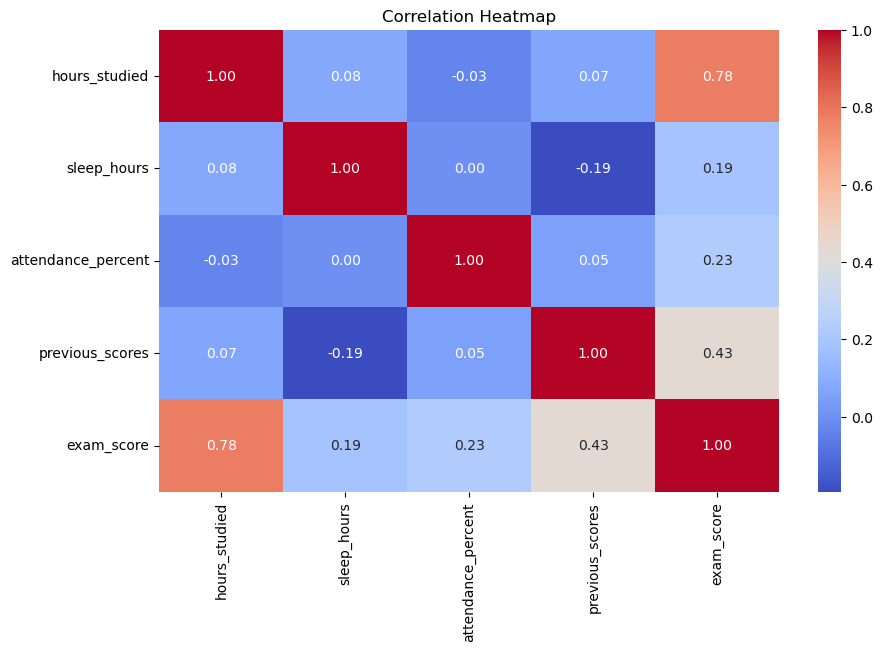

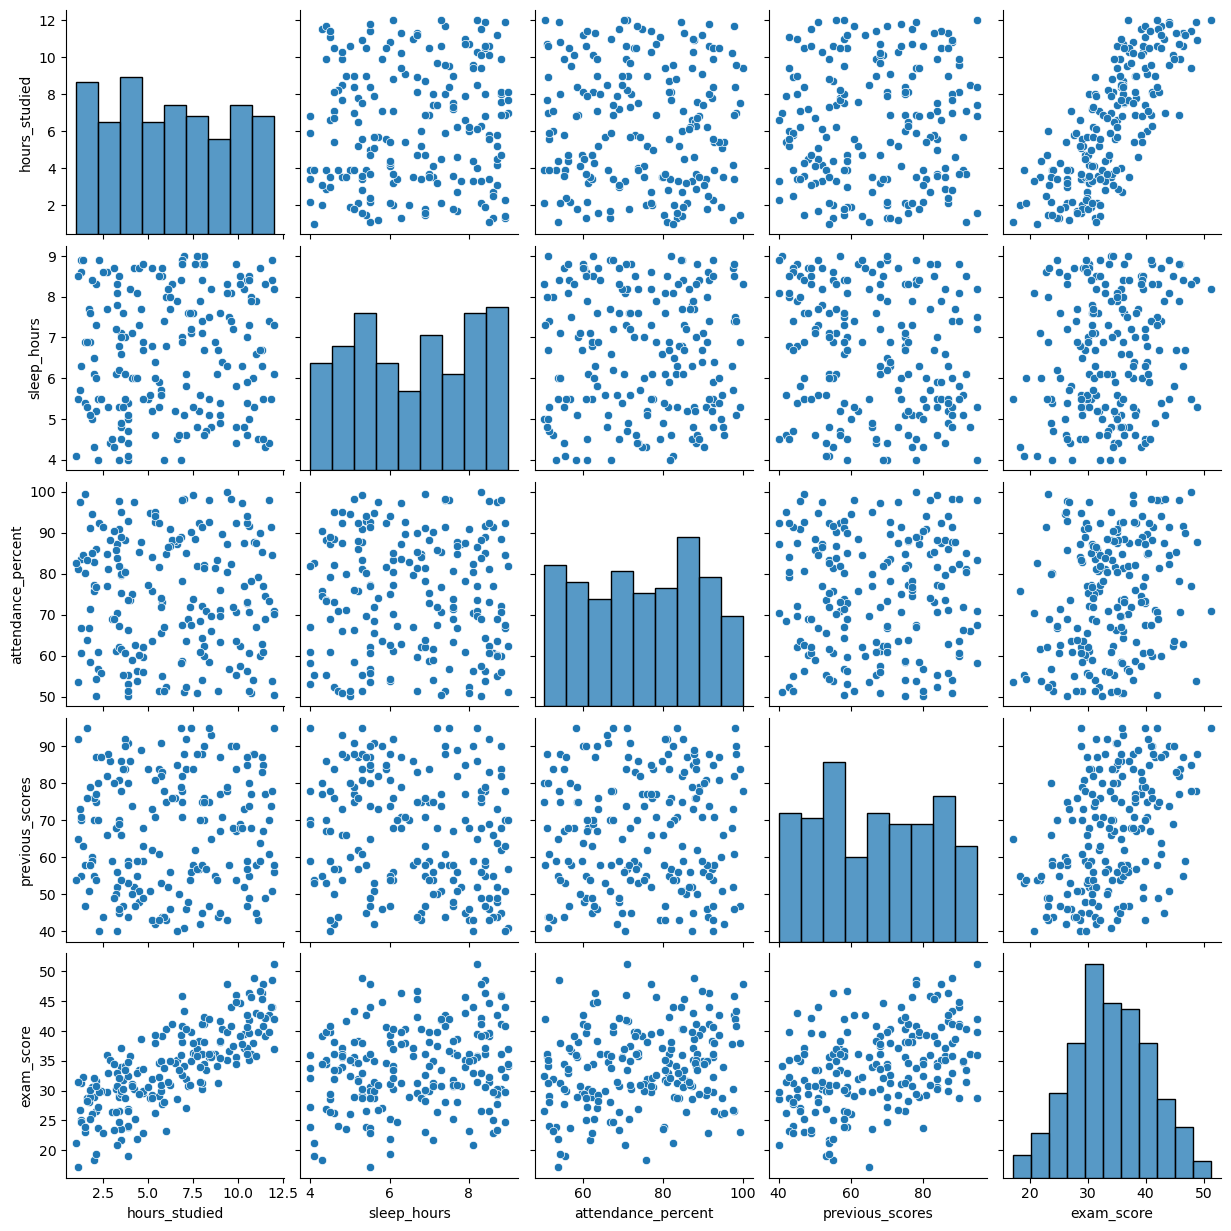

In [80]:
# Correlation Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Pairplot to see relationships
sns.pairplot(df)
plt.show()

## 5. Feature Selection
We identify our features (X) and target variable (y).

In [81]:
X = df.drop('exam_score', axis=1)
y = df['exam_score']

print("Features:", X.columns.tolist())
print("Target:", 'exam_score')

Features: ['hours_studied', 'sleep_hours', 'attendance_percent', 'previous_scores']
Target: exam_score


## 6. Train Test Split
Split the data into training (80%) and testing (20%) sets.

In [82]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape}")
print(f"Testing set size: {X_test.shape}")

Training set size: (160, 4)
Testing set size: (40, 4)


## 7. Model Training and Accuracy Check
We will use Linear Regression for our prediction model.

In [83]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [84]:

# Check accuracy (R2 Score) on training data
train_score = model.score(X_train, y_train)
print(f"Training Accuracy (R2 Score): {train_score:.4f}")

Training Accuracy (R2 Score): 0.8364


## 8. Prediction
Predicting the exam scores for the test set.

In [85]:
y_pred = model.predict(X_test)

# Comparing Actual vs Predicted
comparison_df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
print(comparison_df.head())

     Actual  Predicted
95     28.7  28.886072
15     34.1  29.680421
30     34.5  35.311956
158    29.5  31.180448
128    36.1  39.448943


## 9. Evaluation
Evaluating the model performance using standard metrics.

Mean Absolute Error: 2.3109
Mean Squared Error: 7.7618
Root Mean Squared Error: 2.7860
R-squared Score: 0.8537


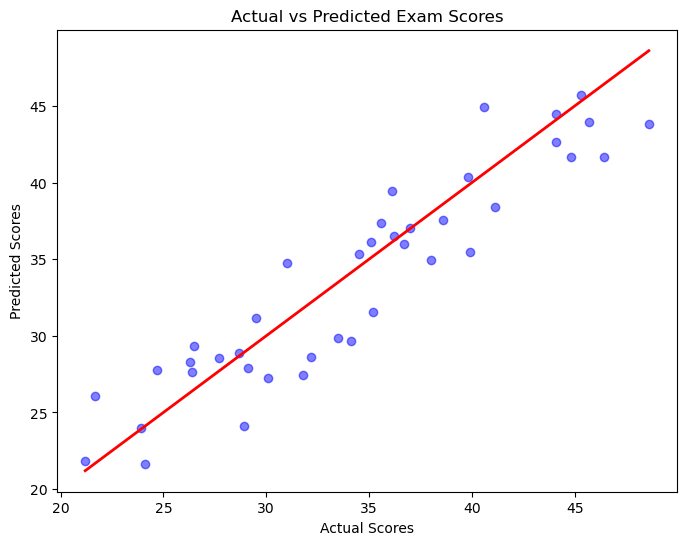

In [86]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.4f}")
print(f"Mean Squared Error: {mse:.4f}")
print(f"Root Mean Squared Error: {rmse:.4f}")
print(f"R-squared Score: {r2:.4f}")

# Visualization of Predicted vs Actual
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.title('Actual vs Predicted Exam Scores')
plt.show()

## 10. Save the Model
We will save the trained model using `joblib` so it can be used for future predictions.

In [87]:
import joblib

# Save the model to a file
joblib.dump(model, 'student_score_model.pkl')

print("Model saved as student_score_model.pkl")

Model saved as student_score_model.pkl
